# RFM Customer Segmentation: Bridging SQL and Python

**Project Overview:** 
This project demonstrates an end-to-end data analysis workflow using an e-commerce dataset ("Online Retail"). The objective is to perform an RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior. By combining the querying power of PostgreSQL with the analytical capabilities of Python, this project identifies key customer groups (from "Champions" to "At Risk") to help drive targeted marketing strategies.

**Author:** Kristina Nunić

**Tools & Techniques Used:**
*   **Database:** PostgreSQL, pgAdmin 4
*   **Programming Language:** Python (Jupyter Lab)
*   **Libraries:** Pandas, SQLAlchemy, psycopg2, Matplotlib, Seaborn
*   **Techniques:** Relational Database Connection, SQL Data Cleaning & Aggregation, Feature Engineering (RFM Scoring), Data Visualization

### 1. Connecting to the PostgreSQL Database

In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Create a connection to the database (replace <YOUR_PASSWORD> with your actual password before running locally)
engine = create_engine('postgresql://postgres:<YOUR_PASSWORD>@localhost:5432/rmf_projekat')

# Write a SQL query in Python
sql_query = "SELECT * FROM prodaja LIMIT 10;"

# Load the query results directly into a Pandas DataFrame
df = pd.read_sql(sql_query, engine)

# Display the first 10 rows
df

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047,United Kingdom


### 2. SQL Data Extraction and Cleaning

In [2]:
# SQL query to check data quality (total rows, missing IDs, canceled orders)
sql_check = """
SELECT 
    COUNT(*) AS total_rows,
    SUM(CASE WHEN customer_id IS NULL OR customer_id = '' THEN 1 ELSE 0 END) AS missing_customer,
    SUM(CASE WHEN quantity <= 0 THEN 1 ELSE 0 END) AS canceled_or_error
FROM prodaja;
"""

# Sending the query to the database and storing the result in a DataFrame
df_check = pd.read_sql(sql_check, engine)
df_check

,total_rows,missing_customer,canceled_or_error
0,541909,135080,10624


In [3]:
# SQL query to filter out missing IDs, negative quantities, and calculate 'total_price'
sql_clean = """
SELECT 
    customer_id,
    invoice_no,
    invoice_date,
    quantity,
    unit_price,
    (quantity * unit_price) AS total_price
FROM prodaja
WHERE customer_id IS NOT NULL 
  AND customer_id != '' 
  AND quantity > 0;
"""

# Extracting clean data via the engine connection directly into a DataFrame
df_clean = pd.read_sql(sql_clean, engine)

# Converting the SQL text date into a proper datetime format to calculate time differences later
df_clean['invoice_date'] = pd.to_datetime(df_clean['invoice_date'])

# Displaying basic information about the new, clean table
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397924 entries, 0 to 397923
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   customer_id   397924 non-null  object        
 1   invoice_no    397924 non-null  object        
 2   invoice_date  397924 non-null  datetime64[ns]
 3   quantity      397924 non-null  int64         
 4   unit_price    397924 non-null  float64       
 5   total_price   397924 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 18.2+ MB


### 3. Calculating RFM Metrics (Recency, Frequency, Monetary)

In [4]:
import datetime as dt

# 1. Determine the reference date (latest date in the dataset + 1 day)
reference_date = df_clean['invoice_date'].max() + dt.timedelta(days=1)

# 2. Group by customer and calculate RFM metrics
rfm = df_clean.groupby('customer_id').agg({
    'invoice_date': lambda x: (reference_date - x.max()).days,  # Recency (days since last purchase)
    'invoice_no': 'nunique',                                    # Frequency (number of unique purchases)
    'total_price': 'sum'                                        # Monetary (total amount spent)
})

# 3. Rename columns for readability
rfm.rename(columns={
    'invoice_date': 'Recency',
    'invoice_no': 'Frequency',
    'total_price': 'Monetary'
}, inplace=True)

# Display the first 5 customers
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### 4. Customer Scoring and Segmentation

In [5]:
# Divide Recency into 4 groups (fewer days = higher score)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

# Divide Frequency into 4 groups (more purchases = higher score)
# We use rank() because many customers have only 1 purchase, preventing bin edge errors
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Divide Monetary into 4 groups (more money spent = higher score)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine scores into a single "RFM Segment" string (e.g., '444' for the best customers)
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Add scores together for a total "RFM Score" (ranging from 3 to 12)
rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Display results
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
customer_id,,,,,,,,
12346,326,1,77183.60,1,1,4,114,6
12347,2,7,4310.00,4,4,4,444,12
12348,75,4,1797.24,2,3,4,234,9
12349,19,1,1757.55,3,1,4,314,8
12350,310,1,334.40,1,1,2,112,4


In [6]:
# Function to assign a segment name based on the total RFM Score
def rfm_level(df):
    if df['RFM_Score'] >= 10:
        return 'Champions'
    elif df['RFM_Score'] >= 8:
        return 'Loyal Customers'
    elif df['RFM_Score'] >= 6:
        return 'Potential Loyalist'
    elif df['RFM_Score'] >= 4:
        return 'At Risk'
    else:
        return 'Lost'

# Apply the function to each row in the DataFrame to create a new column
rfm['Customer_Segment'] = rfm.apply(rfm_level, axis=1)

# Display the first 5 customers with their new segments
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
customer_id,,,,,,,,,
12346,326,1,77183.60,1,1,4,114,6,Potential Loyalist
12347,2,7,4310.00,4,4,4,444,12,Champions
12348,75,4,1797.24,2,3,4,234,9,Loyal Customers
12349,19,1,1757.55,3,1,4,314,8,Loyal Customers
12350,310,1,334.40,1,1,2,112,4,At Risk


In [7]:
# Count the number of customers in each segment
segment_counts = rfm['Customer_Segment'].value_counts()
print(segment_counts)

Customer_Segment
Champions             1268
At Risk                988
Potential Loyalist     938
Loyal Customers        843
Lost                   302
Name: count, dtype: int64


### 5. Data Visualization and Business Insights

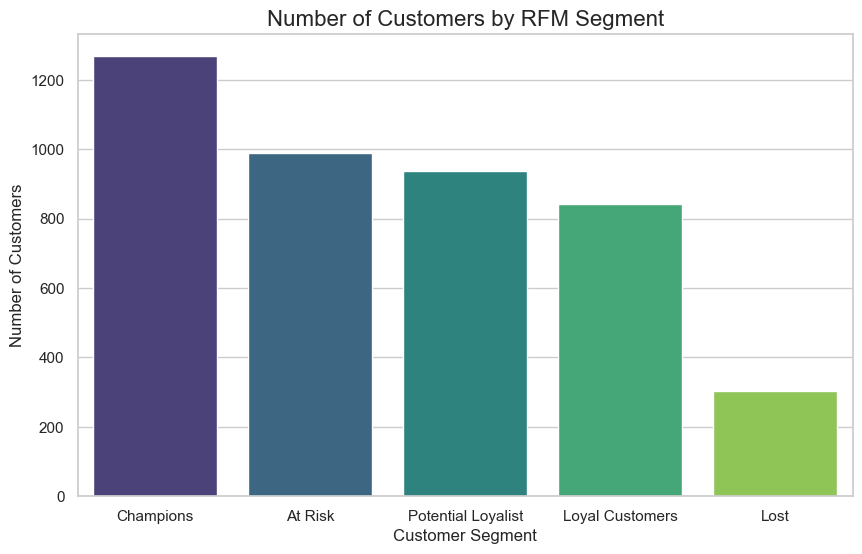

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size and style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a bar chart using the updated Seaborn syntax
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, palette="viridis", legend=False)

# Add title and axis labels
plt.title('Number of Customers by RFM Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Display the chart
plt.show()

### 6. Conclusion and Business Recommendations

This RFM analysis successfully transformed raw transactional data into actionable customer segments. By evaluating Recency, Frequency, and Monetary metrics, we gained valuable insights into the current customer base:

* **Strong Core Base:** The largest group consists of **Champions** (1,268 customers). These are the most valuable customers who buy recently, frequently, and spend the most. The business should focus on rewarding them to maintain loyalty.
* **Retention Opportunity:** A significant portion of the customer base (988 customers) is classified as **At Risk**. These customers used to purchase often and spend large amounts, but haven't interacted with the business recently. 

**Recommendation:** The marketing team should immediately launch a targeted re-engagement campaign (e.g., personalized emails, surveys, or exclusive discounts) specifically aimed at the "At Risk" segment to prevent them from becoming permanently "Lost."